impor Libararies

In [190]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay



load data

In [191]:
file="heart_failure_clinical_records_dataset.csv"
data=pd.read_csv(file)
data.head()
data.tail()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
294,62.0,0,61,1,38,1,155000.0,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.0,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.0,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.0,1.4,140,1,1,280,0
298,50.0,0,196,0,45,0,395000.0,1.6,136,1,1,285,0


processing

In [192]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [193]:
data.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [194]:
data.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

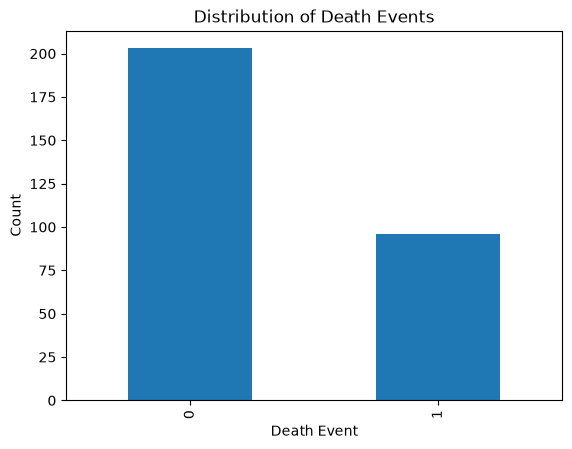

In [195]:
data["DEATH_EVENT"].value_counts().plot(kind="bar")

plt.xlabel("Death Event")
plt.ylabel("Count")
plt.title("Distribution of Death Events")
plt.show()

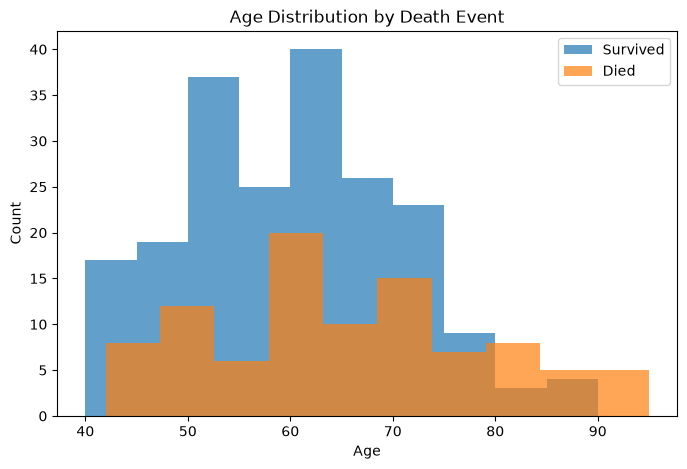

In [196]:
survived = data[data["DEATH_EVENT"] == 0]["age"]
died = data[data["DEATH_EVENT"] == 1]["age"]
plt.figure(figsize=(8,5))

plt.hist(survived, bins=10, alpha=0.7, label="Survived")
plt.hist(died, bins=10, alpha=0.7, label="Died")

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution by Death Event")
plt.legend()

plt.show()

In [197]:
num_cols = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
creatinine_phosphokinase: 29 outliers
ejection_fraction: 2 outliers
platelets: 21 outliers
serum_creatinine: 29 outliers
serum_sodium: 4 outliers
time: 0 outliers


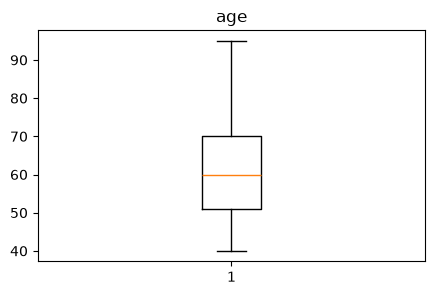

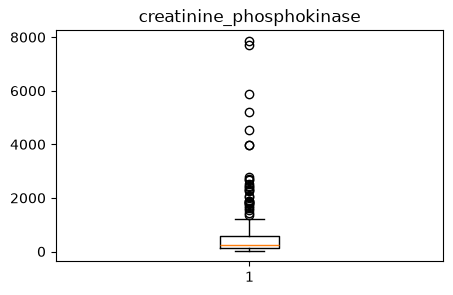

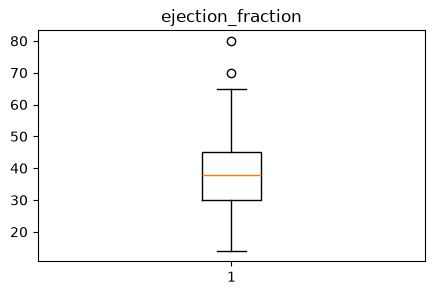

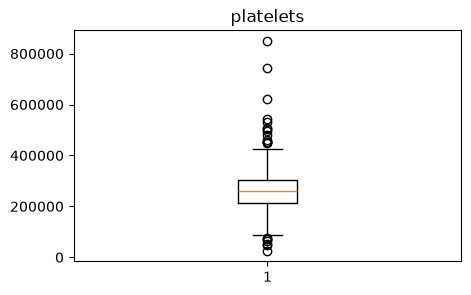

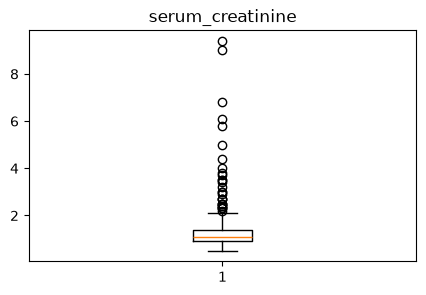

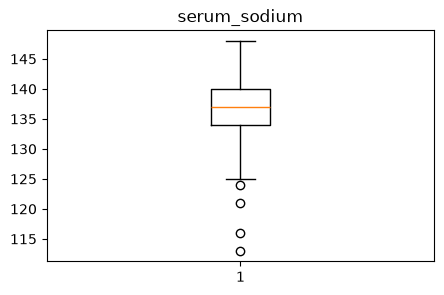

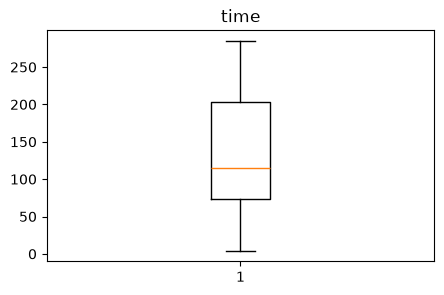

In [198]:
num_cols = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

for col in num_cols:
    plt.figure(figsize=(5,3))
    plt.boxplot(data[col])
    plt.title(col)
    plt.show()

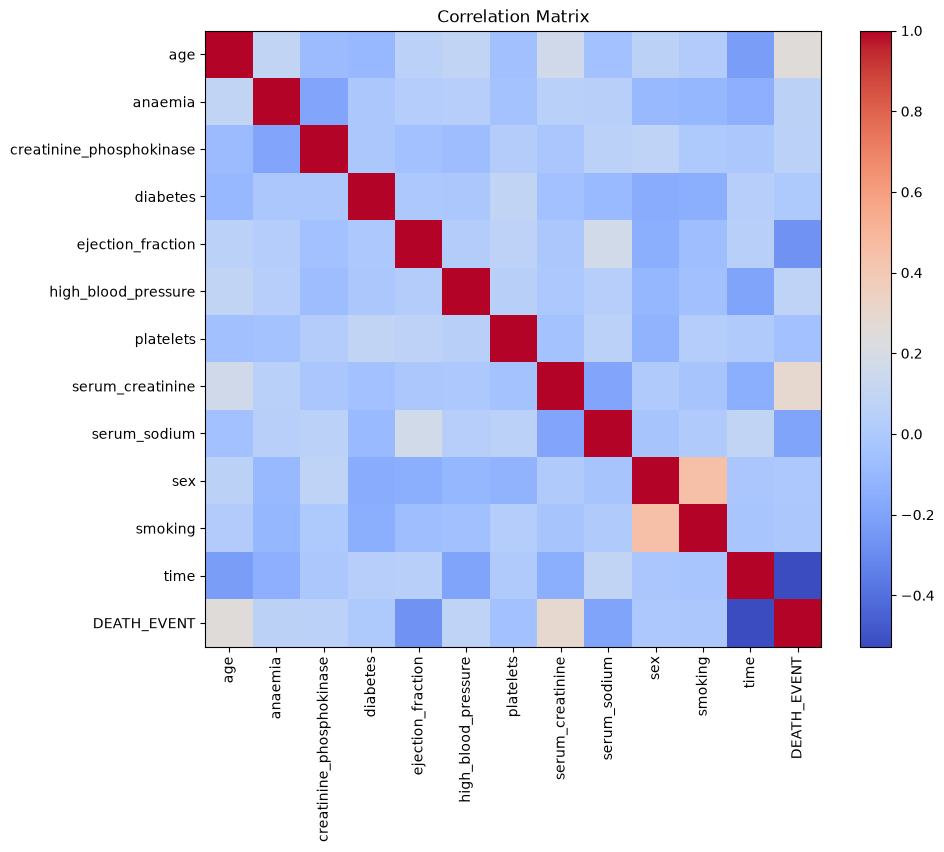

In [199]:
import matplotlib.pyplot as plt

corr_matrix = data.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr_matrix, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Correlation Matrix")
plt.show()

In [200]:
data.corr()["DEATH_EVENT"].sort_values(ascending=False)

DEATH_EVENT                 1.000000
serum_creatinine            0.294278
age                         0.253729
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
diabetes                   -0.001943
sex                        -0.004316
smoking                    -0.012623
platelets                  -0.049139
serum_sodium               -0.195204
ejection_fraction          -0.268603
time                       -0.526964
Name: DEATH_EVENT, dtype: float64

MODEL BUILDING

In [201]:

X = data.drop(["DEATH_EVENT"], axis=1)
Y=data["DEATH_EVENT"]

In [202]:
scaler=StandardScaler().set_output(transform="pandas")
X_scaled=scaler.fit_transform(X)
X_scaled.describe()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
count,2.990000e+02,2.990000e+02,299.000000,2.990000e+02,2.990000e+02,299.000000,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02
mean,5.703353e-16,1.009969e-16,0.000000,9.060014e-17,-3.267546e-17,0.000000,7.723291e-17,1.425838e-16,-8.673849e-16,-8.911489e-18,-1.188199e-17,-1.901118e-16
std,1.001676e+00,1.001676e+00,1.001676,1.001676e+00,1.001676e+00,1.001676,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00
min,-1.754448e+00,-8.711048e-01,-0.576918,-8.475794e-01,-2.038387e+00,-0.735688,-2.440155e+00,-8.655094e-01,-5.363206e+00,-1.359272e+00,-6.876819e-01,-1.629502e+00
25%,-8.281242e-01,-8.711048e-01,-0.480393,-8.475794e-01,-6.841802e-01,-0.735688,-5.208700e-01,-4.782047e-01,-5.959961e-01,-1.359272e+00,-6.876819e-01,-7.389995e-01
50%,-7.022315e-02,-8.711048e-01,-0.342574,-8.475794e-01,-7.076750e-03,-0.735688,-1.390846e-02,-2.845524e-01,8.503384e-02,7.356882e-01,-6.876819e-01,-1.969543e-01
75%,7.718891e-01,1.147968e+00,0.000166,1.179830e+00,5.853888e-01,1.359272,4.111199e-01,5.926150e-03,7.660638e-01,7.356882e-01,1.454161e+00,9.387595e-01
max,2.877170e+00,1.147968e+00,7.514640,1.179830e+00,3.547716e+00,1.359272,6.008180e+00,7.752020e+00,2.582144e+00,7.356882e-01,1.454161e+00,1.997038e+00


In [203]:
X_train,X_test,Y_train,Y_test=train_test_split(X_scaled,Y,test_size=0.30,stratify=Y,random_state=42)

In [204]:
print(X_train.head())
print(X_test.head())
print(Y_train.head())
print(Y_test.head())




          age   anaemia  creatinine_phosphokinase  ...       sex   smoking      time
186 -0.912335 -0.871105                  0.000166  ... -1.359272 -0.687682  0.538678
258 -1.333392  1.147968                 -0.532527  ...  0.735688 -0.687682  1.287217
104 -0.070223 -0.871105                 -0.545947  ... -1.359272 -0.687682 -0.558318
161 -1.333392  1.147968                 -0.466456  ...  0.735688  1.454161 -0.119519
263  0.603467  1.147968                 -0.438583  ... -1.359272 -0.687682  1.377558

[5 rows x 12 columns]
          age   anaemia  creatinine_phosphokinase  ...       sex   smoking      time
146 -0.743913 -0.871105                 -0.464392  ...  0.735688  1.454161 -0.235672
226 -0.238646  1.147968                 -0.541818  ...  0.735688  1.454161  0.964571
10   1.192945  1.147968                 -0.517041  ...  0.735688  1.454161 -1.552067
242 -1.754448 -0.871105                 -0.507750  ...  0.735688  1.454161  1.054912
118  0.350833  1.147968                 -0

Text(0, 0.5, 'numbers of instances')

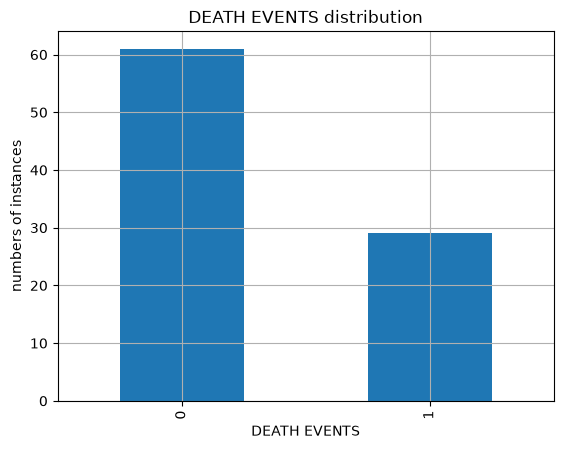

In [205]:
Y_test.value_counts().sort_index().plot.bar(grid="true")
plt.title("DEATH EVENTS distribution")
plt.xlabel("DEATH EVENTS")
plt.ylabel("numbers of instances")

Text(0, 0.5, 'numbers of instances')

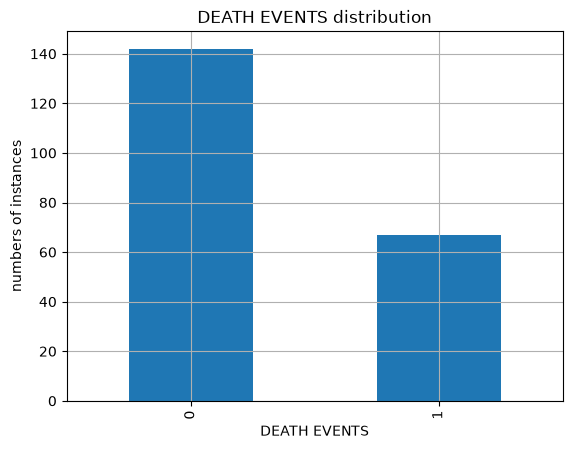

In [206]:
Y_train.value_counts().sort_index().plot.bar(grid="true")
plt.title("DEATH EVENTS distribution")
plt.xlabel("DEATH EVENTS")
plt.ylabel("numbers of instances")

SUPPORT VECTORE MACHINE 

In [207]:
print("using support vectore machine")
svm_model=svm.LinearSVC(class_weight="balanced")
svm_model.fit(X_train,Y_train)
prediction=svm_model.predict(X_test)
print("accuracy score:",accuracy_score(Y_test,prediction)*100)
print("precision score:",precision_score(Y_test,prediction)*100)
print("recall score:",recall_score(Y_test,prediction)*100)
print("f1 score:",f1_score(Y_test,prediction)*100)



using support vectore machine
accuracy score: 78.88888888888889
precision score: 67.85714285714286
recall score: 65.51724137931035
f1 score: 66.66666666666666


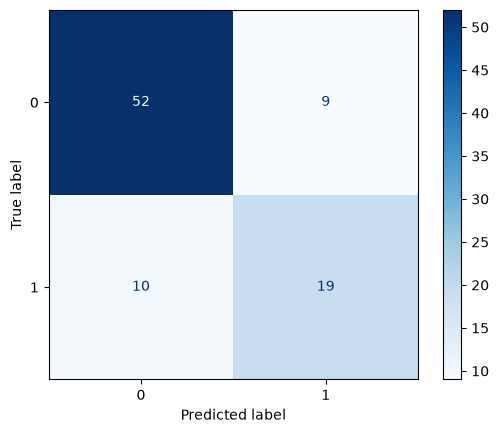

In [208]:


ConfusionMatrixDisplay.from_estimator(
    svm_model, 
    X_test, 
    Y_test, 
    cmap='Blues' 
)

plt.show()

KNeighborsClassifier

In [209]:
print("using Kneighbors classifier")
Knn_model=KNeighborsClassifier()
Knn_model.fit(X_train,Y_train)
prediction=Knn_model.predict(X_test)
print("accuracy score:",accuracy_score(Y_test,prediction)*100)
print("precision score:",precision_score(Y_test,prediction)*100)
print("recall score:",recall_score(Y_test,prediction)*100)
print("f1 score:",f1_score(Y_test,prediction)*100)



using Kneighbors classifier
accuracy score: 70.0
precision score: 57.14285714285714
recall score: 27.586206896551722
f1 score: 37.2093023255814


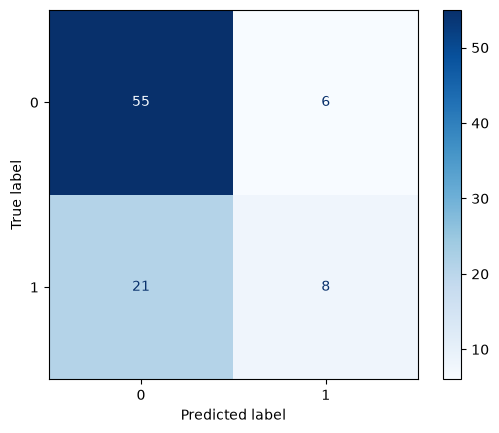

In [210]:


ConfusionMatrixDisplay.from_estimator(
    Knn_model, 
    X_test, 
    Y_test, 
    cmap='Blues' 
)

plt.show()

Logistic Regression

In [211]:
print("using logistic regression")
Lr_model=LogisticRegression(class_weight="balanced")
Lr_model.fit(X_train,Y_train)
prediction=Lr_model.predict(X_test)
print("accuracy score:",accuracy_score(Y_test,prediction)*100)
print("precision score:",precision_score(Y_test,prediction)*100)
print("recall score:",recall_score(Y_test,prediction)*100)
print("f1 score:",f1_score(Y_test,prediction)*100)



using logistic regression
accuracy score: 78.88888888888889
precision score: 67.85714285714286
recall score: 65.51724137931035
f1 score: 66.66666666666666


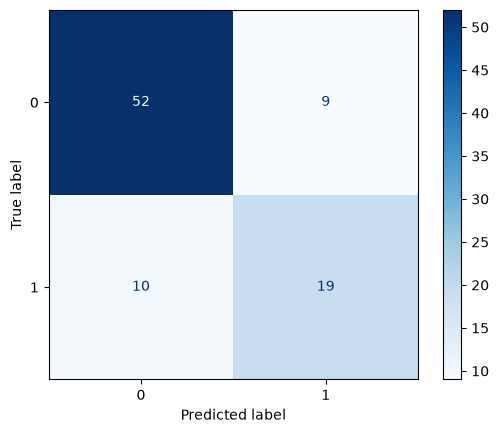

In [212]:
ConfusionMatrixDisplay.from_estimator(
    Lr_model, 
    X_test, 
    Y_test, 
    cmap='Blues' 
)

plt.show()